### Austin Animal Shelter Adoption Data Cleaning

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

intakes = pd.read_csv('aac_intakes.csv')
intakes_outcomes = pd.read_csv('aac_intakes_outcomes.csv')
outcomes = pd.read_csv('aac_outcomes.csv')

df = pd.concat([intakes, intakes_outcomes, outcomes])

In [18]:
animal_data = df[['outcome_type', 'age_upon_intake', 'age_upon_outcome', 'animal_type', 'breed', 'color', 'intake_condition', 'intake_type', 'sex_upon_intake', 'datetime', 'outcome_datetime', 'time_in_shelter','date_of_birth']].copy()

animal_data = animal_data.rename(
    columns={
        'animal_type' : "Animal_Type",
        'date_of_birth' : "DOB",
        'breed' : "Breed",
        'color' : "Color",
        'sex_upon_intake' : "Sex",
        'datetime' : "Intake_Date",
        'intake_condition': "Intake_Condition",  
        'intake_type' : "Intake_Type",
        'outcome_datetime' : "Outcome_Date",
        'outcome_type' : "Outcome_Type",
        'age_upon_intake' : "Intake_Age",
        'age_upon_outcome' : "Outcome_Age",
        'time_in_shelter' : 'Days_in_Shelter'
    }
)


In [19]:
sample = animal_data.sample(100)

In [20]:
animal_data.describe()

,Outcome_Type,Intake_Age,Outcome_Age,Animal_Type,Breed,Color,Intake_Condition,Intake_Type,Sex,Intake_Date,Outcome_Date,Days_in_Shelter,DOB
count,160329,159859,160345,240540,240540,240540,159859,159859,159857,160868,79672,79672,160353
unique,9,46,46,5,2183,532,8,5,5,123529,65686,29319,11879
top,Adoption,1 year,1 year,Dog,Domestic Shorthair Mix,Black/White,Normal,Stray,Intact Male,2016-09-23T12:00:00.000,2016-04-18 00:00:00,0 days 00:14:00.000000000,2014-05-05 00:00:00
freq,67826,29252,29661,136965,70763,25006,140576,112215,50805,64,39,77,112


In [21]:
animal_data['Intake_Date'] = pd.to_datetime(animal_data['Intake_Date'], errors='coerce')
animal_data['Outcome_Date'] = pd.to_datetime(animal_data['Outcome_Date'], errors='coerce')

animal_data = animal_data.astype( 
    {
        'Outcome_Type' : 'category',
        'Intake_Age' : 'object',
        'Outcome_Age' : 'object',
        'Animal_Type' : 'category',
        'Breed' : 'object',
        'Color' : 'category',
        'Intake_Condition' : 'category',
        'Intake_Type' : 'category',
        'Sex' : 'category',
        'Intake_Date' : 'datetime64[ns]',
        'Outcome_Date' : 'datetime64[ns]',
        'Days_in_Shelter' : 'object'
    }
)

animal_data['Days_in_Shelter'] = pd.to_timedelta(animal_data['Days_in_Shelter'])

In [22]:
'''animal_data['Intake_Date'] = animal_data['Intake_Date'].fillna(
    animal_data['Outcome_Date'] - pd.to_timedelta(animal_data['Days_in_Shelter'], unit='D')
)'''

animal_data['Intake_Date'] = animal_data['Intake_Date'].fillna(animal_data['Outcome_Date'] - animal_data['Days_in_Shelter'])


animal_data['Shelter_Name'] = 'Austin Texas Animal Shelter'

animal_data[['Primary_Color', 'Secondary_Color']] = animal_data['Color'].str.split('/', n=1, expand=True)
animal_data['Secondary_Color'] = animal_data['Secondary_Color'].fillna("None")
animal_data.drop(columns={'Color'}, inplace=True)

def getDays(text):
    if isinstance(text, str) and ' ' in text:
        num, time = text.split(" ")
        num = int(num)
        if time.lower() == 'days':
            return num
        if time.lower() == 'months':
            return int(num * 30)
        if time.lower() == 'years':
            return int(num * 365.25)
    elif isinstance(text, (int, float)):
        return float(text)
    return 0  # for any NA

animal_data['Intake_Age'] = animal_data['Intake_Age'].apply(getDays)

animal_data['Days_in_Shelter'] = animal_data['Days_in_Shelter'].astype(str).str.extract(r'(\d+)').astype(float)

print(animal_data.shape)

(240540, 15)


In [23]:
print(f'Columns: {animal_data.columns}')
print(f'Types: {animal_data.dtypes}')
print(f'Shape: {animal_data.shape}')

Columns: Index(['Outcome_Type', 'Intake_Age', 'Outcome_Age', 'Animal_Type', 'Breed',
       'Intake_Condition', 'Intake_Type', 'Sex', 'Intake_Date', 'Outcome_Date',
       'Days_in_Shelter', 'DOB', 'Shelter_Name', 'Primary_Color',
       'Secondary_Color'],
      dtype='object')
Types: Outcome_Type              category
Intake_Age                 float64
Outcome_Age                 object
Animal_Type               category
Breed                       object
Intake_Condition          category
Intake_Type               category
Sex                       category
Intake_Date         datetime64[ns]
Outcome_Date        datetime64[ns]
Days_in_Shelter            float64
DOB                         object
Shelter_Name                object
Primary_Color               object
Secondary_Color             object
dtype: object
Shape: (240540, 15)


In [24]:
missing_values = animal_data.isna().sum()
print(f"Missing values:\n {missing_values}")

duplicated_values = animal_data.duplicated().sum()
print(f"Duplicated Values: {duplicated_values}")
animal_data = animal_data.drop_duplicates()
print("Duplicated Values Dropped")

print(f'Shape: {animal_data.shape}')
animal_data = animal_data.reset_index(drop=True)

Missing values:
 Outcome_Type         80211
Intake_Age           80681
Outcome_Age          80195
Animal_Type              0
Breed                    0
Intake_Condition     80681
Intake_Type          80681
Sex                  80683
Intake_Date          80681
Outcome_Date        160868
Days_in_Shelter     160868
DOB                  80187
Shelter_Name             0
Primary_Color            0
Secondary_Color          0
dtype: int64
Duplicated Values: 16299
Duplicated Values Dropped
Shape: (224241, 15)


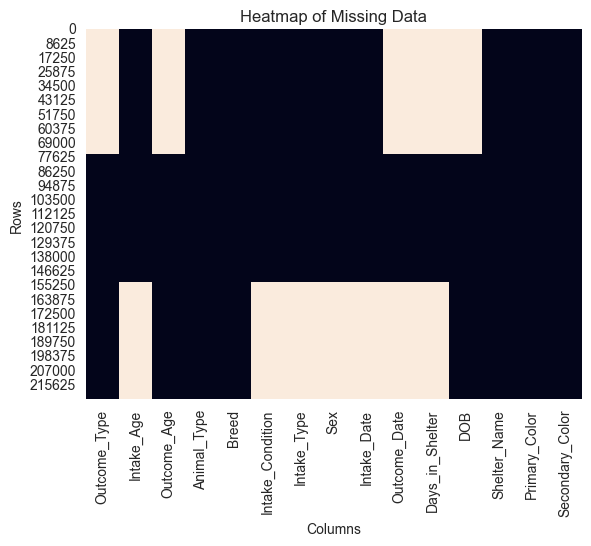

In [25]:
sns.heatmap(animal_data.isnull(), cbar=False)
plt.title("Heatmap of Missing Data")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

After a visual inspection, it is most likely that certain features were not recorded until a certain timeframe possibly due to data collection policy or data entry errors.

In [26]:
print(animal_data.shape)
animal_data.dropna(inplace=True)
print(animal_data.shape)

(224241, 15)
(77896, 15)


In [34]:
animal_data.to_csv('Austin_Animal_Data.csv', index=False)
print(animal_data.columns)

Index(['Outcome_Type', 'Intake_Age', 'Outcome_Age', 'Animal_Type', 'Breed',
       'Intake_Condition', 'Intake_Type', 'Sex', 'Intake_Date', 'Outcome_Date',
       'Days_in_Shelter', 'DOB', 'Shelter_Name', 'Primary_Color',
       'Secondary_Color'],
      dtype='object')


In [29]:
animal_data.head(100)

,Outcome_Type,Intake_Age,Outcome_Age,Animal_Type,Breed,Intake_Condition,Intake_Type,Sex,Intake_Date,Outcome_Date,Days_in_Shelter,DOB,Shelter_Name,Primary_Color,Secondary_Color
75435,Return to Owner,3652.0,10 years,Dog,Spinone Italiano Mix,Normal,Stray,Neutered Male,2017-12-07 00:00:00,2017-12-07 14:07:00,0.0,2007-07-09 00:00:00,Austin Texas Animal Shelter,Yellow,White
75436,Return to Owner,2556.0,7 years,Dog,Spinone Italiano Mix,Normal,Public Assist,Neutered Male,2014-12-19 10:21:00,2014-12-20 16:35:00,1.0,2007-07-09 00:00:00,Austin Texas Animal Shelter,Yellow,White
75437,Return to Owner,2191.0,6 years,Dog,Spinone Italiano Mix,Normal,Public Assist,Neutered Male,2014-03-07 14:26:00,2014-03-08 17:10:00,1.0,2007-07-09 00:00:00,Austin Texas Animal Shelter,Yellow,White
75438,Transfer,3652.0,10 years,Dog,Dachshund,Normal,Owner Surrender,Neutered Male,2014-04-02 15:55:00,2014-04-07 15:12:00,4.0,2004-04-02 00:00:00,Austin Texas Animal Shelter,Tricolor,None
75439,Return to Owner,5844.0,16 years,Dog,Shetland Sheepdog,Injured,Public Assist,Neutered Male,2013-11-16 09:02:00,2013-11-16 11:54:00,0.0,1997-10-16 00:00:00,Austin Texas Animal Shelter,Brown,White
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75530,Return to Owner,5478.0,15 years,Dog,Golden Retriever Mix,Normal,Stray,Spayed Female,2017-02-25 14:02:00,2017-02-25 16:35:00,0.0,2002-02-10 00:00:00,Austin Texas Animal Shelter,Gold,None
75531,Return to Owner,4748.0,13 years,Dog,German Shepherd Mix,Normal,Public Assist,Neutered Male,2014-10-01 15:41:00,2014-10-08 16:13:00,7.0,2001-08-18 00:00:00,Austin Texas Animal Shelter,Tan,None
75532,Euthanasia,4748.0,13 years,Cat,Domestic Shorthair,Normal,Stray,Neutered Male,2016-04-27 18:17:00,2016-05-23 12:54:00,25.0,2003-04-19 00:00:00,Austin Texas Animal Shelter,Brown Tabby,None
75533,Adoption,4383.0,12 years,Cat,Domestic Shorthair,Normal,Owner Surrender,Neutered Male,2015-06-13 14:41:00,2015-07-31 17:02:00,48.0,2003-04-19 00:00:00,Austin Texas Animal Shelter,Brown Tabby,None


In [35]:
animal_data['Days_in_Shelter'].value_counts()

Days_in_Shelter
0.0      17524
4.0       8113
1.0       5126
5.0       4746
3.0       4193
         ...  
364.0        1
604.0        1
493.0        1
870.0        1
489.0        1
Name: count, Length: 466, dtype: int64

In [33]:
animal_data.columns

Index(['Outcome_Type', 'Intake_Age', 'Outcome_Age', 'Animal_Type', 'Breed',
       'Intake_Condition', 'Intake_Type', 'Sex', 'Intake_Date', 'Outcome_Date',
       'Days_in_Shelter', 'DOB', 'Shelter_Name', 'Primary_Color',
       'Secondary_Color'],
      dtype='object')